# 01 - Data Loading & Feature Engineering

Load STOXX 600 price data from the PRICE ATLAS Excel file, convert to long
format, compute return and volatility features, add country/region, build a
synthetic equal-weight benchmark, plot, and save to processed CSV.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100})

## 1. Load raw data

In [2]:
DATA_PATH = Path("../data/raw/stoxx600/2025_2026_PRICE_ATLAS_data_sxxr_static.xlsx")
PROCESSED_DIR = Path("../data/processed/stoxx600")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# --- Stock prices (wide) ---
prices_wide = pd.read_excel(DATA_PATH, sheet_name="price")
prices_wide = prices_wide.rename(columns={"Ticker": "date"})
prices_wide["date"] = pd.to_datetime(prices_wide["date"])
prices_wide = prices_wide.set_index("date").sort_index()

print(f"Wide matrix : {prices_wide.shape[0]} dates x {prices_wide.shape[1]} stocks")
print(f"Date range  : {prices_wide.index[0].date()} -> {prices_wide.index[-1].date()}")
print(f"NaN fraction: {prices_wide.isna().mean().mean():.2%}")

Wide matrix : 3464 dates x 600 stocks
Date range  : 2013-01-01 -> 2026-04-10
NaN fraction: 6.30%


In [3]:
# --- SXXR benchmark ---
benchmark_raw = pd.read_excel(DATA_PATH, sheet_name="benchmark")
benchmark_raw["Date"] = pd.to_datetime(benchmark_raw["Date"])
benchmark_raw = benchmark_raw.set_index("Date").sort_index()

sxxr = benchmark_raw["price"].copy()
sxxr.name = "SXXR"
print(f"SXXR index  : {sxxr.shape[0]} dates")

SXXR index  : 3464 dates


## 2. Convert to long format & add features

In [4]:
# Melt wide -> long: (date, ticker, price)
df = (
    prices_wide
    .stack(future_stack=True)
    .reset_index()
    .rename(columns={"level_1": "ticker", 0: "price"})
)
df = df.dropna(subset=["price"]).sort_values(["ticker", "date"]).reset_index(drop=True)
print(f"Long format : {len(df):,} rows  |  {df['ticker'].nunique()} tickers")
df.head()

Long format : 1,947,399 rows  |  597 tickers


,date,ticker,price
0,2013-01-01,A2A IM,0.2441
1,2013-01-02,A2A IM,0.2581
2,2013-01-03,A2A IM,0.2552
3,2013-01-04,A2A IM,0.2547
4,2013-01-07,A2A IM,0.2595


In [5]:
# --- Return & volatility features (computed per ticker) ---
df = df.sort_values(["ticker", "date"])
g = df.groupby("ticker")["price"]

# Log returns
log_price = np.log(df["price"])
for d, label in [(1, "1d"), (20, "20d"), (252, "252d")]:
    df[f"{label}_log_ret"] = g.transform(lambda s: np.log(s).diff(d))

# Arithmetic returns
for d, label in [(1, "1d"), (20, "20d"), (252, "252d")]:
    df[f"{label}_arith_ret"] = g.transform(lambda s: s.pct_change(d))

# Realised volatility (annualised, based on 1d log returns)
log_ret_1d = g.transform(lambda s: np.log(s).diff(1))
for w, label in [(20, "20d"), (60, "60d"), (252, "252d")]:
    df[f"{label}_vol"] = (
        log_ret_1d
        .groupby(df["ticker"])
        .transform(lambda s: s.rolling(w, min_periods=w).std() * np.sqrt(252))
    )

print(f"Features added. Columns: {list(df.columns)}")
df.head(10)

Features added. Columns: ['date', 'ticker', 'price', '1d_log_ret', '20d_log_ret', '252d_log_ret', '1d_arith_ret', '20d_arith_ret', '252d_arith_ret', '20d_vol', '60d_vol', '252d_vol']


,date,ticker,price,1d_log_ret,20d_log_ret,252d_log_ret,1d_arith_ret,20d_arith_ret,252d_arith_ret,20d_vol,60d_vol,252d_vol
0,2013-01-01,A2A IM,0.2441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,A2A IM,0.2581,0.055769,NaN,NaN,0.057354,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,A2A IM,0.2552,-0.011300,NaN,NaN,-0.011236,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,A2A IM,0.2547,-0.001961,NaN,NaN,-0.001959,NaN,NaN,NaN,NaN,NaN
4,2013-01-07,A2A IM,0.2595,0.018670,NaN,NaN,0.018846,NaN,NaN,NaN,NaN,NaN
5,2013-01-08,A2A IM,0.2600,0.001925,NaN,NaN,0.001927,NaN,NaN,NaN,NaN,NaN
6,2013-01-09,A2A IM,0.2644,0.016781,NaN,NaN,0.016923,NaN,NaN,NaN,NaN,NaN
7,2013-01-10,A2A IM,0.2634,-0.003789,NaN,NaN,-0.003782,NaN,NaN,NaN,NaN,NaN
8,2013-01-11,A2A IM,0.2641,0.002654,NaN,NaN,0.002658,NaN,NaN,NaN,NaN,NaN
9,2013-01-14,A2A IM,0.2565,-0.029199,NaN,NaN,-0.028777,NaN,NaN,NaN,NaN,NaN


In [6]:
# --- Country & region from exchange suffix ---
EXCHANGE_TO_COUNTRY = {
    "LN": "United Kingdom",
    "FP": "France",
    "GY": "Germany",
    "NA": "Netherlands",
    "IM": "Italy",
    "SQ": "Spain",
    "SE": "Switzerland",
    "SS": "Sweden",
    "DC": "Denmark",
    "FH": "Finland",
    "NO": "Norway",
    "BB": "Belgium",
    "AV": "Austria",
    "PL": "Portugal",
    "ID": "Ireland",
    "PW": "Poland",
}

COUNTRY_TO_REGION = {
    "United Kingdom": "UK & Ireland",
    "Ireland": "UK & Ireland",
    "France": "Western Europe",
    "Germany": "Western Europe",
    "Netherlands": "Western Europe",
    "Belgium": "Western Europe",
    "Austria": "Western Europe",
    "Switzerland": "Western Europe",
    "Italy": "Southern Europe",
    "Spain": "Southern Europe",
    "Portugal": "Southern Europe",
    "Sweden": "Nordic",
    "Denmark": "Nordic",
    "Finland": "Nordic",
    "Norway": "Nordic",
    "Poland": "Eastern Europe",
}

df["exchange"] = df["ticker"].str.split().str[-1]
df["country"] = df["exchange"].map(EXCHANGE_TO_COUNTRY)
df["region"] = df["country"].map(COUNTRY_TO_REGION)

print("Country distribution:")
print(df.groupby("country")["ticker"].nunique().sort_values(ascending=False))
print("\nRegion distribution:")
print(df.groupby("region")["ticker"].nunique().sort_values(ascending=False))

Country distribution:
country
United Kingdom    129
France             71
Germany            67
Sweden             60
Switzerland        60
Italy              41
Netherlands        35
Denmark            25
Spain              25
Finland            20
Norway             18
Belgium            17
Poland             10
Austria             8
Ireland             6
Portugal            5
Name: ticker, dtype: int64

Region distribution:
region
Western Europe     258
UK & Ireland       135
Nordic             123
Southern Europe     71
Eastern Europe      10
Name: ticker, dtype: int64


In [7]:
# Final column order
cols = [
    "date", "ticker", "price",
    "1d_log_ret", "20d_log_ret", "252d_log_ret",
    "1d_arith_ret", "20d_arith_ret", "252d_arith_ret",
    "20d_vol", "60d_vol", "252d_vol",
    "exchange", "country", "region",
]
df = df[cols].sort_values(["date", "ticker"]).reset_index(drop=True)
print(f"Final stock df : {len(df):,} rows x {len(df.columns)} cols")
df.head(10)

Final stock df : 1,947,399 rows x 15 cols


,date,ticker,price,1d_log_ret,20d_log_ret,252d_log_ret,1d_arith_ret,20d_arith_ret,252d_arith_ret,20d_vol,60d_vol,252d_vol,exchange,country,region
0,2013-01-01,A2A IM,0.2441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IM,Italy,Southern Europe
1,2013-01-01,AAK SS,38.4910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SS,Sweden,Nordic
2,2013-01-01,AAL LN,1096.4180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LN,United Kingdom,UK & Ireland
3,2013-01-01,AALB NA,11.6589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NA,Netherlands,Western Europe
4,2013-01-01,ABBN SE,11.7295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE,Switzerland,Western Europe
5,2013-01-01,ABDN LN,133.0940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LN,United Kingdom,UK & Ireland
6,2013-01-01,ABF LN,1222.7160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LN,United Kingdom,UK & Ireland
7,2013-01-01,ABI BB,48.7600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,Belgium,Western Europe
8,2013-01-01,AC FP,20.4963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FP,France,Western Europe
9,2013-01-01,ACA FP,3.1391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FP,France,Western Europe


## 3. Build benchmarks

**SXXR** (cap-weighted) comes from the file.  
**EW** (equal-weight) is built from daily arithmetic returns, averaged across
all available stocks, then cumulated from base 100.

In [8]:
# --- Equal-weight benchmark from wide prices ---
ew_return = prices_wide.pct_change().mean(axis=1)
ew_index = 100 * (1 + ew_return).cumprod()
ew_index.iloc[0] = 100

# --- Assemble benchmark df: date, benchmark, price ---
sxxr_df = pd.DataFrame({"date": sxxr.index, "benchmark": "SXXR", "price": sxxr.values})
ew_df = pd.DataFrame({"date": ew_index.index, "benchmark": "EW", "price": ew_index.values})
benchmarks = pd.concat([sxxr_df, ew_df], ignore_index=True).sort_values(["date", "benchmark"]).reset_index(drop=True)

print(f"Benchmark df : {len(benchmarks):,} rows")
benchmarks.head()

Benchmark df : 6,928 rows


,date,benchmark,price
0,2013-01-01,EW,100.000000
1,2013-01-01,SXXR,496.770000
2,2013-01-02,EW,102.072424
3,2013-01-02,SXXR,506.830000
4,2013-01-03,EW,102.446170


## 4. Plots

In [9]:
STOCK = "ASML NA"

# Rebase helper
def rebase(s):
    """Rebase a series to 100 on first valid value."""
    s = s.dropna()
    return 100 * s / s.iloc[0]

In [ ]:
# Single stock
stock_prices = df.loc[df["ticker"] == STOCK].set_index("date")["price"]


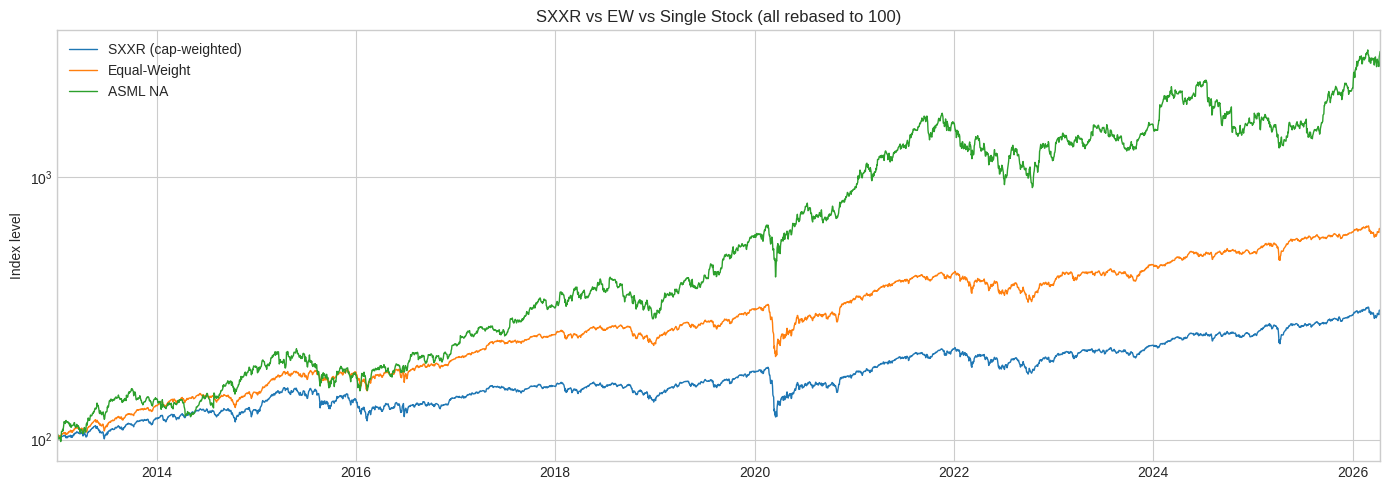

In [15]:
# All three rebased to 100
fig, ax = plt.subplots()
rebase(sxxr).plot(ax=ax, linewidth=1, label="SXXR (cap-weighted)", logy=True)
ew_index.plot(ax=ax, linewidth=1, label="Equal-Weight")
rebase(stock_prices).plot(ax=ax, linewidth=1, label=STOCK)
ax.set_title("SXXR vs EW vs Single Stock (all rebased to 100)")
ax.set_ylabel("Index level")
ax.set_xlabel("")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Save to processed CSV

In [14]:
stock_path = PROCESSED_DIR / "stoxx600_processed.csv"
bench_path = PROCESSED_DIR / "benchmark_stoxx600_ew.csv"

df.to_csv(stock_path, index=False)
benchmarks.to_csv(bench_path, index=False)

print(f"Saved stocks     -> {stock_path}  ({stock_path.stat().st_size / 1e6:.1f} MB)")
print(f"Saved benchmarks -> {bench_path}  ({bench_path.stat().st_size / 1e6:.1f} MB)")

Saved stocks     -> ../data/processed/stoxx600/stoxx600_processed.csv  (443.6 MB)
Saved benchmarks -> ../data/processed/stoxx600/benchmark_stoxx600_ew.csv  (0.2 MB)
